In [1]:
import pandas as pd

file_path = r"C:\Users\ATHARVA\Downloads\my codes\python\machine_learning\project_web\balanced_final_phishing_df.csv"

balanced_final_phishing_df= pd.read_csv(file_path)

In [2]:
from pprint import pprint

In [3]:
pprint(balanced_final_phishing_df.iloc[10]['body'])

("SF Weekly:  >Nothing's more enticing than an evening cruise around San "
 'Francisco Bay,   >and the islands, bridges, and lights of the city are '
 'especially entrancing   >viewed from this vintage brigantine schooner. Built '
 'in 1933 and recently   >restored to its former glory, the 78-foot Rendezvous '
 'looks like a clipper   >ship out of the Gold Rush era, with its 80-foot '
 'masts and square-rigged   >sails.    That sounds like fun. But it sets the '
 "wrong precedent.  Here's the better idea. Invite her for an afternoon  "
 'cruise under the Golden Gate bridge in your Stonehorse  day sailor. Under '
 "way, ask her if she'd like to take  the stick. Back at slip, cook her "
 'dinner. Something  simple, but good, maybe a stir fry or a stew, served  in '
 'the cockpit, with an inexpensive but potable wine.    If she runs away after '
 "that, 'tis good riddance. If  she wants to try it again, another day, she "
 'shows  promise. If she asks you to show her the V berth, you  hav

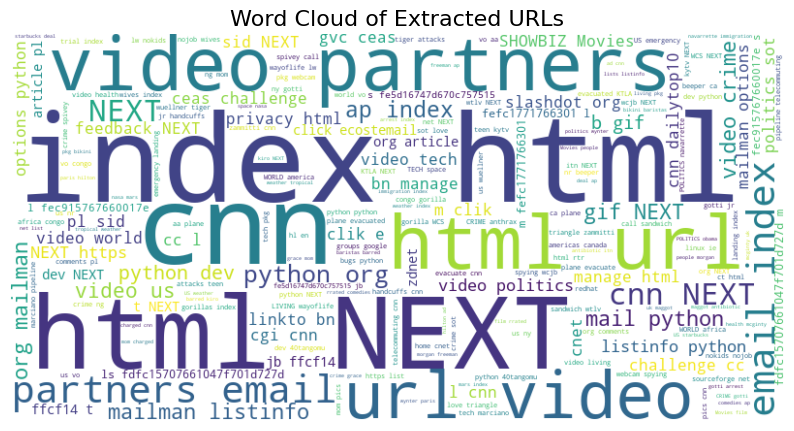

In [4]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Combine all URLs into one string (drop NaN and convert to str)
url_text = " ".join(balanced_final_phishing_df['URL'].dropna().astype(str))

# Generate the word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=200
).generate(url_text)

# Plot the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Extracted URLs", fontsize=16)
plt.show()

In [5]:
work_data=balanced_final_phishing_df[['text_combined','URL','URL_COUNT','label']]

In [6]:
work_data

,text_combined,URL,URL_COUNT,label
0,[SSUB] CNN.com Daily Top 10 [ESUB] [SBODY] >+=...,http://www.cnn.com/video/partners/email/index....,24,1
1,[SSUB] [ILUG] What to do when the stock market...,http://80.71.65.57/ [NEXT] http://80.71.65.57/...,4,1
2,[SSUB] Upcoming Workshop [ESUB] [SBODY] Join o...,NaN,0,0
3,[SSUB] Virtueller Messetag der jobfair24 am Mi...,http://www.jobfair24.de/virtualworldmbatour/st...,10,0
4,[SSUB] Meet other Singles just like you [ESUB]...,http://click.emailrewardz.email-publisher.com/...,4,1
...,...,...,...,...
43001,[SSUB] [Py2exe-users] Py2exe and Json [ESUB] ...,http://ad.doubleclick.net/clk;198757673;135030...,2,0
43002,"[SSUB] [UAI] Microsoft Research, Cambridge is ...",http://www.research.microsoft.com/aboutmsr/job...,1,0
43003,[SSUB] MedsPhentrimineInternationalPharmacy [E...,http://1ivyzw.bay.livefilestore.com/y1pE_wFRNk...,1,1
43004,[SSUB] Re: [perl #46463] filetests sometimes d...,NaN,0,0


In [7]:
URL_DATA=balanced_final_phishing_df[['URL','label']]

In [8]:
URL_DATA['URL']

0        http://www.cnn.com/video/partners/email/index....
1        http://80.71.65.57/ [NEXT] http://80.71.65.57/...
2                                                      NaN
3        http://www.jobfair24.de/virtualworldmbatour/st...
4        http://click.emailrewardz.email-publisher.com/...
                               ...                        
43001    http://ad.doubleclick.net/clk;198757673;135030...
43002    http://www.research.microsoft.com/aboutmsr/job...
43003    http://1ivyzw.bay.livefilestore.com/y1pE_wFRNk...
43004                                                  NaN
43005                                                  NaN
Name: URL, Length: 43006, dtype: object

In [9]:
import re

# Use of IP or not in domain
def having_ip_address(url):
    match = re.search(
        '(([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.'
        '([01]?\\d\\d?|2[0-4]\\d|25[0-5]))|'  # IPv4
        '((0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2}))|'  # IPv4 in hex
        '(?:[a-fA-F0-9]{1,4}:){7}[a-fA-F0-9]{1,4}', url)  # IPv6
    return 1 if match else 0

# Apply function while skipping NaNs
work_data['USE_OF_IP'] = work_data['URL'].apply(lambda i: having_ip_address(i) if pd.notnull(i) else 0)

C:\Users\ATHARVA\AppData\Local\Temp\ipykernel_9332\1666863658.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  work_data['USE_OF_IP'] = work_data['URL'].apply(lambda i: having_ip_address(i) if pd.notnull(i) else 0)


In [11]:
import pandas as pd
from urllib.parse import urlparse

# --- Helper functions ---
def split_urls(sample):
    """Split a sample into individual URLs by [NEXT]."""
    if pd.isna(sample):
        return []
    return [u.strip() for u in sample.split('[NEXT]') if u.strip()]

def url_length(url):
    """Return length of a URL string."""
    return len(url)

def subdomain_count(url):
    """Return number of subdomains in a URL."""
    try:
        hostname = urlparse(url).hostname
        if hostname is None:
            return 0
        parts = hostname.split('.')
        # subtract domain + TLD
        return max(len(parts) - 2, 0)
    except:
        return 0

def extract_features(sample):
    """Compute max/avg URL length and subdomain count for a sample."""
    urls = split_urls(sample)
    if not urls:
        return pd.Series([0, 0, 0, 0], 
                         index=['url_length_max','url_length_avg','url_subdom_max','url_subdom_avg'])
    
    lengths = [url_length(u) for u in urls]
    subdoms = [subdomain_count(u) for u in urls]
    
    return pd.Series([
        max(lengths),
        sum(lengths)/len(lengths),
        max(subdoms),
        sum(subdoms)/len(subdoms)
    ], index=['url_length_max','url_length_avg','url_subdom_max','url_subdom_avg'])

# --- Apply to your DataFrame ---
work_data[['url_length_max','url_length_avg','url_subdom_max','url_subdom_avg']] = \
    work_data['URL'].apply(extract_features)

In [12]:
work_data

,text_combined,URL,URL_COUNT,label,USE_OF_IP,url_length_max,url_length_avg,url_subdom_max,url_subdom_avg
0,[SSUB] CNN.com Daily Top 10 [ESUB] [SBODY] >+=...,http://www.cnn.com/video/partners/email/index....,24,1,0,114.0,80.166667,1.0,1.00
1,[SSUB] [ILUG] What to do when the stock market...,http://80.71.65.57/ [NEXT] http://80.71.65.57/...,4,1,1,41.0,27.250000,2.0,1.75
2,[SSUB] Upcoming Workshop [ESUB] [SBODY] Join o...,NaN,0,0,0,0.0,0.000000,0.0,0.00
3,[SSUB] Virtueller Messetag der jobfair24 am Mi...,http://www.jobfair24.de/virtualworldmbatour/st...,10,0,0,71.0,53.800000,1.0,1.00
4,[SSUB] Meet other Singles just like you [ESUB]...,http://click.emailrewardz.email-publisher.com/...,4,1,0,67.0,61.000000,2.0,1.75
...,...,...,...,...,...,...,...,...,...
43001,[SSUB] [Py2exe-users] Py2exe and Json [ESUB] ...,http://ad.doubleclick.net/clk;198757673;135030...,2,0,0,78.0,67.500000,1.0,1.00
43002,"[SSUB] [UAI] Microsoft Research, Cambridge is ...",http://www.research.microsoft.com/aboutmsr/job...,1,0,0,75.0,75.000000,2.0,2.00
43003,[SSUB] MedsPhentrimineInternationalPharmacy [E...,http://1ivyzw.bay.livefilestore.com/y1pE_wFRNk...,1,1,0,136.0,136.000000,2.0,2.00
43004,[SSUB] Re: [perl #46463] filetests sometimes d...,NaN,0,0,0,0.0,0.000000,0.0,0.00


In [13]:

import re
import pandas as pd

shortening_pattern = re.compile(
    r'bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|'
    r'yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|'
    r'short\.to|BudURL\.com|ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|'
    r'doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|lnkd\.in|'
    r'db\.tt|qr\.ae|adf\.ly|bitly\.com|cur\.lv|tinyurl\.com|ity\.im|'
    r'q\.gs|po\.st|bc\.vc|twitthis\.com|u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|'
    r'prettylinkpro\.com|scrnch\.me|filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|'
    r'tr\.im|link\.zip\.net',
    re.IGNORECASE
)

def count_shortened_urls(sample):
    """Count how many shortened URLs appear in a sample (split by [NEXT])."""
    if pd.isna(sample):
        return 0
    urls = [u.strip() for u in sample.split('[NEXT]') if u.strip()]
    return sum(1 for u in urls if shortening_pattern.search(u))

# Apply to your DataFrame
work_data['short_url_count'] = work_data['URL'].apply(count_shortened_urls)

In [14]:
work_data

,text_combined,URL,URL_COUNT,label,USE_OF_IP,url_length_max,url_length_avg,url_subdom_max,url_subdom_avg,short_url_count
0,[SSUB] CNN.com Daily Top 10 [ESUB] [SBODY] >+=...,http://www.cnn.com/video/partners/email/index....,24,1,0,114.0,80.166667,1.0,1.00,0
1,[SSUB] [ILUG] What to do when the stock market...,http://80.71.65.57/ [NEXT] http://80.71.65.57/...,4,1,1,41.0,27.250000,2.0,1.75,0
2,[SSUB] Upcoming Workshop [ESUB] [SBODY] Join o...,NaN,0,0,0,0.0,0.000000,0.0,0.00,0
3,[SSUB] Virtueller Messetag der jobfair24 am Mi...,http://www.jobfair24.de/virtualworldmbatour/st...,10,0,0,71.0,53.800000,1.0,1.00,0
4,[SSUB] Meet other Singles just like you [ESUB]...,http://click.emailrewardz.email-publisher.com/...,4,1,0,67.0,61.000000,2.0,1.75,0
...,...,...,...,...,...,...,...,...,...,...
43001,[SSUB] [Py2exe-users] Py2exe and Json [ESUB] ...,http://ad.doubleclick.net/clk;198757673;135030...,2,0,0,78.0,67.500000,1.0,1.00,0
43002,"[SSUB] [UAI] Microsoft Research, Cambridge is ...",http://www.research.microsoft.com/aboutmsr/job...,1,0,0,75.0,75.000000,2.0,2.00,1
43003,[SSUB] MedsPhentrimineInternationalPharmacy [E...,http://1ivyzw.bay.livefilestore.com/y1pE_wFRNk...,1,1,0,136.0,136.000000,2.0,2.00,0
43004,[SSUB] Re: [perl #46463] filetests sometimes d...,NaN,0,0,0,0.0,0.000000,0.0,0.00,0


In [15]:
import re
import pandas as pd

# Compile regex once for efficiency
suspicious_pattern = re.compile(
    # Your original keywords
    r'PayPal|login|signin|bank|account|update|free|lucky|service|bonus|ebayisapi|webscr'
    
    # Urgency & Security
    r'|verify|secure|password|support|alert|warning|confirm|suspend|action-required'
    r'|activity|limited|access-restricted|authentication|recover|reset'
    
    # Financial
    r'|invoice|payment|billing|purchase|transaction|refund'
    
    # Common Brands (add more as needed)
    r'|microsoft|google|amazon|apple|netflix|fedex|dhl|ups'
    
    # Technical & Deceptive Files
    r'|redirect|cgi-bin|admin|\.exe|\.zip|\.rar|\.js|\.scr|\.bat|\.php'
    
    # Suspicious TLDs (note the escaped dot `\.`)
    r'|\.xyz|\.top|\.icu|\.biz|\.info|\.live|\.link|\.click'
    ,
    re.IGNORECASE
)

def suspicious_words_count(sample):
    """Count how many suspicious keywords appear across all URLs in a sample."""
    if pd.isna(sample):
        return 0
    urls = [u.strip() for u in sample.split('[NEXT]') if u.strip()]
    return sum(1 for u in urls if suspicious_pattern.search(u))

work_data['sus_url_count'] = work_data['URL'].apply(suspicious_words_count)

work_data['sus_url_flag'] = (work_data['sus_url_count'] > 0).astype(int)

In [16]:
work_data

,text_combined,URL,URL_COUNT,label,USE_OF_IP,url_length_max,url_length_avg,url_subdom_max,url_subdom_avg,short_url_count,sus_url_count,sus_url_flag
0,[SSUB] CNN.com Daily Top 10 [ESUB] [SBODY] >+=...,http://www.cnn.com/video/partners/email/index....,24,1,0,114.0,80.166667,1.0,1.00,0,0,0
1,[SSUB] [ILUG] What to do when the stock market...,http://80.71.65.57/ [NEXT] http://80.71.65.57/...,4,1,1,41.0,27.250000,2.0,1.75,0,0,0
2,[SSUB] Upcoming Workshop [ESUB] [SBODY] Join o...,NaN,0,0,0,0.0,0.000000,0.0,0.00,0,0,0
3,[SSUB] Virtueller Messetag der jobfair24 am Mi...,http://www.jobfair24.de/virtualworldmbatour/st...,10,0,0,71.0,53.800000,1.0,1.00,0,6,1
4,[SSUB] Meet other Singles just like you [ESUB]...,http://click.emailrewardz.email-publisher.com/...,4,1,0,67.0,61.000000,2.0,1.75,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
43001,[SSUB] [Py2exe-users] Py2exe and Json [ESUB] ...,http://ad.doubleclick.net/clk;198757673;135030...,2,0,0,78.0,67.500000,1.0,1.00,0,0,0
43002,"[SSUB] [UAI] Microsoft Research, Cambridge is ...",http://www.research.microsoft.com/aboutmsr/job...,1,0,0,75.0,75.000000,2.0,2.00,1,1,1
43003,[SSUB] MedsPhentrimineInternationalPharmacy [E...,http://1ivyzw.bay.livefilestore.com/y1pE_wFRNk...,1,1,0,136.0,136.000000,2.0,2.00,0,1,1
43004,[SSUB] Re: [perl #46463] filetests sometimes d...,NaN,0,0,0,0.0,0.000000,0.0,0.00,0,0,0


In [17]:
# --- Dot count helper ---
def dot_count(url):
    """Count total dots in the full URL string."""
    return url.count('.') if url else 0

def extract_dot_features(sample):
    """Compute max/avg dot count across multiple URLs in a sample."""
    urls = split_urls(sample)
    if not urls:
        return pd.Series([0, 0], index=['dot_count_max','dot_count_avg'])
    
    dots = [dot_count(u) for u in urls]
    return pd.Series([
        max(dots),
        sum(dots)/len(dots)
    ], index=['dot_count_max','dot_count_avg'])

# --- Apply to your DataFrame ---
work_data[['dot_count_max','dot_count_avg']] = work_data['URL'].apply(extract_dot_features)


In [18]:
work_data

,text_combined,URL,URL_COUNT,label,USE_OF_IP,url_length_max,url_length_avg,url_subdom_max,url_subdom_avg,short_url_count,sus_url_count,sus_url_flag,dot_count_max,dot_count_avg
0,[SSUB] CNN.com Daily Top 10 [ESUB] [SBODY] >+=...,http://www.cnn.com/video/partners/email/index....,24,1,0,114.0,80.166667,1.0,1.00,0,0,0,8.0,5.208333
1,[SSUB] [ILUG] What to do when the stock market...,http://80.71.65.57/ [NEXT] http://80.71.65.57/...,4,1,1,41.0,27.250000,2.0,1.75,0,0,0,4.0,3.000000
2,[SSUB] Upcoming Workshop [ESUB] [SBODY] Join o...,NaN,0,0,0,0.0,0.000000,0.0,0.00,0,0,0,0.0,0.000000
3,[SSUB] Virtueller Messetag der jobfair24 am Mi...,http://www.jobfair24.de/virtualworldmbatour/st...,10,0,0,71.0,53.800000,1.0,1.00,0,6,1,3.0,2.900000
4,[SSUB] Meet other Singles just like you [ESUB]...,http://click.emailrewardz.email-publisher.com/...,4,1,0,67.0,61.000000,2.0,1.75,0,0,0,3.0,3.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43001,[SSUB] [Py2exe-users] Py2exe and Json [ESUB] ...,http://ad.doubleclick.net/clk;198757673;135030...,2,0,0,78.0,67.500000,1.0,1.00,0,0,0,4.0,3.000000
43002,"[SSUB] [UAI] Microsoft Research, Cambridge is ...",http://www.research.microsoft.com/aboutmsr/job...,1,0,0,75.0,75.000000,2.0,2.00,1,1,1,4.0,4.000000
43003,[SSUB] MedsPhentrimineInternationalPharmacy [E...,http://1ivyzw.bay.livefilestore.com/y1pE_wFRNk...,1,1,0,136.0,136.000000,2.0,2.00,0,1,1,4.0,4.000000
43004,[SSUB] Re: [perl #46463] filetests sometimes d...,NaN,0,0,0,0.0,0.000000,0.0,0.00,0,0,0,0.0,0.000000


In [19]:
# import pandas as pd
# from googlesearch import search   # pip install googlesearch-python

# def split_urls(sample):
#     """Split a sample into individual URLs by [NEXT]."""
#     if pd.isna(sample):
#         return []
#     return [u.strip() for u in sample.split('[NEXT]') if u.strip()]

# def google_index(url):
#     """Check if a single URL is indexed by Google."""
#     try:
#         results = list(search(url, num_results=5))
#         return 1 if results else 0
#     except Exception:
#         # If search fails (e.g., network error), treat as not indexed
#         return 0

# def any_not_indexed(sample):
#     """Return 1 if any URL in the sample is not indexed, else 0."""
#     urls = split_urls(sample)
#     if not urls:
#         return 1  # no URLs → treat as abnormal
#     for u in urls:
#         if google_index(u) == 0:
#             return 1
#     return 0

# work_data['any_not_indexed'] = work_data['URL'].apply(any_not_indexed)

In [20]:
import pandas as pd

# --- Generic helpers ---
def split_urls(sample):
    """Split a sample into individual URLs by [NEXT]."""
    if pd.isna(sample):
        return []
    return [u.strip() for u in sample.split('[NEXT]') if u.strip()]

def char_count(url, char):
    """Count occurrences of a given character in a URL string."""
    return url.count(char) if url else 0

def extract_char_features(sample, char, name):
    """Compute max/avg count of a character across multiple URLs in a sample."""
    urls = split_urls(sample)
    if not urls:
        return pd.Series([0, 0], index=[f'{name}_max', f'{name}_avg'])
    
    counts = [char_count(u, char) for u in urls]
    return pd.Series([
        max(counts),
        sum(counts)/len(counts)
    ], index=[f'{name}_max', f'{name}_avg'])

In [21]:
# Percent sign %
work_data[['perc_max','perc_avg']] = work_data['URL'].apply(
    lambda x: extract_char_features(x, '%', 'perc')
)

# Question mark ?
work_data[['ques_max','ques_avg']] = work_data['URL'].apply(
    lambda x: extract_char_features(x, '?', 'ques')
)

# Hyphen -
work_data[['hyphen_max','hyphen_avg']] = work_data['URL'].apply(
    lambda x: extract_char_features(x, '-', 'hyphen')
)

# Equal sign =
work_data[['equal_max','equal_avg']] = work_data['URL'].apply(
    lambda x: extract_char_features(x, '=', 'equal')
)

In [22]:
work_data

,text_combined,URL,URL_COUNT,label,USE_OF_IP,url_length_max,url_length_avg,url_subdom_max,url_subdom_avg,short_url_count,...,dot_count_max,dot_count_avg,perc_max,perc_avg,ques_max,ques_avg,hyphen_max,hyphen_avg,equal_max,equal_avg
0,[SSUB] CNN.com Daily Top 10 [ESUB] [SBODY] >+=...,http://www.cnn.com/video/partners/email/index....,24,1,0,114.0,80.166667,1.0,1.00,0,...,8.0,5.208333,0.0,0.0,1.0,0.458333,2.0,0.083333,2.0,0.5
1,[SSUB] [ILUG] What to do when the stock market...,http://80.71.65.57/ [NEXT] http://80.71.65.57/...,4,1,1,41.0,27.250000,2.0,1.75,0,...,4.0,3.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
2,[SSUB] Upcoming Workshop [ESUB] [SBODY] Join o...,NaN,0,0,0,0.0,0.000000,0.0,0.00,0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
3,[SSUB] Virtueller Messetag der jobfair24 am Mi...,http://www.jobfair24.de/virtualworldmbatour/st...,10,0,0,71.0,53.800000,1.0,1.00,0,...,3.0,2.900000,0.0,0.0,1.0,0.100000,1.0,0.600000,1.0,0.1
4,[SSUB] Meet other Singles just like you [ESUB]...,http://click.emailrewardz.email-publisher.com/...,4,1,0,67.0,61.000000,2.0,1.75,0,...,3.0,3.000000,0.0,0.0,1.0,0.250000,1.0,0.750000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43001,[SSUB] [Py2exe-users] Py2exe and Json [ESUB] ...,http://ad.doubleclick.net/clk;198757673;135030...,2,0,0,78.0,67.500000,1.0,1.00,0,...,4.0,3.000000,0.0,0.0,1.0,0.500000,1.0,0.500000,0.0,0.0
43002,"[SSUB] [UAI] Microsoft Research, Cambridge is ...",http://www.research.microsoft.com/aboutmsr/job...,1,0,0,75.0,75.000000,2.0,2.00,1,...,4.0,4.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
43003,[SSUB] MedsPhentrimineInternationalPharmacy [E...,http://1ivyzw.bay.livefilestore.com/y1pE_wFRNk...,1,1,0,136.0,136.000000,2.0,2.00,0,...,4.0,4.000000,0.0,0.0,0.0,0.000000,1.0,1.000000,0.0,0.0
43004,[SSUB] Re: [perl #46463] filetests sometimes d...,NaN,0,0,0,0.0,0.000000,0.0,0.00,0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0


In [23]:
work_data.columns

Index(['text_combined', 'URL', 'URL_COUNT', 'label', 'USE_OF_IP',
       'url_length_max', 'url_length_avg', 'url_subdom_max', 'url_subdom_avg',
       'short_url_count', 'sus_url_count', 'sus_url_flag', 'dot_count_max',
       'dot_count_avg', 'perc_max', 'perc_avg', 'ques_max', 'ques_avg',
       'hyphen_max', 'hyphen_avg', 'equal_max', 'equal_avg'],
      dtype='object')

In [24]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

model_path = r"C:\Users\ATHARVA\Downloads\my codes\python\machine_learning\project_web\DistilBert_Finetuned"

tokenizer = DistilBertTokenizerFast.from_pretrained(model_path)
model_load = DistilBertForSequenceClassification.from_pretrained(model_path)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_load.to(device)

print(f"✅ Model and tokenizer loaded successfully on: {device}")






✅ Model and tokenizer loaded successfully on: cuda


In [26]:
def get_cls_embedding(text, model, tokenizer, device):
    model.eval()
    with torch.no_grad():
        # Tokenize
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=256
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Get hidden states from DistilBERT
        outputs = model.distilbert(**inputs)

        # CLS token (first token) embedding
        cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()

    return cls_embedding




In [28]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(work_data, test_size=0.1, random_state=42, stratify=work_data['label'])


In [41]:
train_df.to_csv("train_df.csv", index=False)

In [42]:
test_df.to_csv("test_df.csv", index=False)

In [29]:
train_embeddings = [get_cls_embedding(text, model_load, tokenizer, device) for text in train_df['text_combined']]
test_embeddings  = [get_cls_embedding(text, model_load, tokenizer, device) for text in test_df['text_combined']]

X_train_text = np.vstack(train_embeddings)
X_test_text  = np.vstack(test_embeddings)


In [32]:
url_features = [
    'URL_COUNT', 'USE_OF_IP', 'url_length_max', 'url_length_avg',
    'url_subdom_max', 'url_subdom_avg', 'short_url_count',
    'sus_url_count', 'sus_url_flag', 'dot_count_max', 'dot_count_avg',
    'perc_max', 'perc_avg', 'ques_max', 'ques_avg',
    'hyphen_max', 'hyphen_avg', 'equal_max', 'equal_avg'
]

X_train_url = train_df[url_features].to_numpy(dtype=np.float32)
X_test_url  = test_df[url_features].to_numpy(dtype=np.float32)


In [33]:
X_train = np.concatenate([X_train_text, X_train_url], axis=1)
X_test  = np.concatenate([X_test_text, X_test_url], axis=1)

y_train = train_df["label"].values
y_test  = test_df["label"].values


In [30]:
save_path = r"C:\Users\ATHARVA\Downloads\my codes\python\machine_learning\project_web\X_train_text.npy"
np.save(save_path, np.vstack(X_train_text))
print(f"✅ Saved embeddings to: {save_path}")

✅ Saved embeddings to: C:\Users\ATHARVA\Downloads\my codes\python\machine_learning\project_web\X_train_text.npy


In [31]:
save_path = r"C:\Users\ATHARVA\Downloads\my codes\python\machine_learning\project_web\X_test_text.npy"
np.save(save_path, np.vstack(X_test_text ))
print(f"✅ Saved embeddings to: {save_path}")

✅ Saved embeddings to: C:\Users\ATHARVA\Downloads\my codes\python\machine_learning\project_web\X_test_text.npy


In [40]:
import numpy as np

# Define paths
np.save("X_train.npy", X_train)
np.save("X_test.npy", X_test)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)

print("✅ Files saved in current directory.")


✅ Files saved in current directory.


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

xgb_model = XGBClassifier(
    n_estimators=300,          
    learning_rate=0.07,        
    max_depth=6,               
    subsample=0.9,              
    colsample_bytree=0.9,      
    reg_lambda=1,              
    reg_alpha=0.001,                
    use_label_encoder=False,   
    eval_metric='logloss',     
    random_state=42,
    n_jobs=-1                  
)

print("Training XGBoost classifier...")
xgb_model.fit(X_train, y_train)
print(" Training completed.")



🚀 Training XGBoost classifier...


c:\Users\ATHARVA\Downloads\my codes\python\machine_learning\project_web\pro_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:24:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Training completed.



🎯 Test Accuracy: 0.9935

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      2151
           1       0.99      0.99      0.99      2150

    accuracy                           0.99      4301
   macro avg       0.99      0.99      0.99      4301
weighted avg       0.99      0.99      0.99      4301



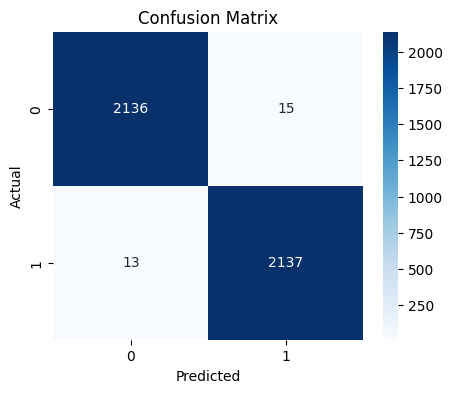

In [ ]:
y_pred = xgb_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 Test Accuracy: {acc:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

# 3  Confusion Matrix Visualization

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()